In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [308]:
df = pd.read_csv("Datasets/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'bmi'}>],
       [<Axes: title={'center': 'children'}>,
        <Axes: title={'center': 'charges'}>]], dtype=object)

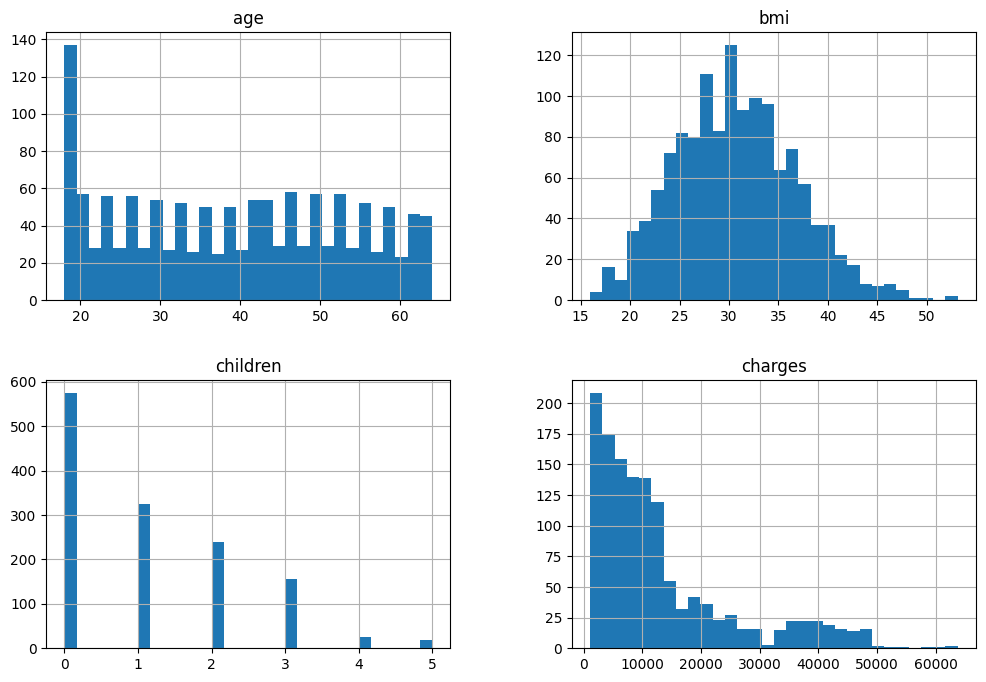

In [309]:
print(df.info())
print(df.describe())
df.hist(bins=30, figsize=(12, 8))

In [310]:
df = pd.get_dummies(df, columns=["sex", "smoker", "region"], drop_first=True)
df = df.astype(int)
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27,0,16884,0,1,0,0,1
1,18,33,1,1725,1,0,0,1,0
2,28,33,3,4449,1,0,0,1,0
3,33,22,0,21984,1,0,1,0,0
4,32,28,0,3866,1,0,1,0,0


In [311]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [312]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [313]:
X = scaler_X.fit_transform(X)
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [314]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [315]:
print("Shape of X_train: ", X_train.shape)
print("Shape of X_test :", X_test.shape)
print("Shape of y_train: ", y_train.shape)
print("Shape of y_test :", y_test.shape)

Shape of X_train:  (1070, 8)
Shape of X_test : (268, 8)
Shape of y_train:  (1070, 1)
Shape of y_test : (268, 1)


In [316]:
def relu(z):
    return np.maximum(0, z)


def relu_derivative(z):
    return (z > 0).astype(float)


def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


def mse_derivative(y_true, y_pred):
    return 2 * (y_true - y_pred) / y_true.size

In [317]:
input_dims = X_train.shape[1]
hidden1 = 64
hidden2 = 32
hidden3 = 16
output_dims = 1

In [318]:
def init_weights(in_dim, out_dims):
    return np.random.randn(in_dim, out_dims) * np.sqrt(2 / in_dim)

In [319]:
W1 = init_weights(input_dims, hidden1)
W2 = init_weights(hidden1, hidden2)
W3 = init_weights(hidden2, hidden3)
W4 = init_weights(hidden3, output_dims)

b1 = np.zeros((1, hidden1))
b2 = np.zeros((1, hidden2))
b3 = np.zeros((1, hidden3))
b4 = np.zeros((1, output_dims))

In [320]:
learning_rate = 0.0001
epochs = 100
losses = []

In [321]:
for epoch in range(epochs):
    z1 = X_train @ W1 + b1
    a1 = relu(z1)

    z2 = a1 @ W2 + b2
    a2 = relu(z2)

    z3 = a2 @ W3 + b3
    a3 = relu(z3)

    z4 = a3 @ W4 + b4
    output = z4

    loss = mse_loss(y_train, output)
    losses.append(loss)

    d_loss = mse_derivative(y_train, output)

    dW4 = a3.T @ d_loss
    db4 = np.sum(d_loss, axis=0, keepdims=True)

    dA3 = d_loss @ W4.T * relu_derivative(z3)
    dW3 = a2.T @ dA3
    db3 = np.sum(dA3, axis=0, keepdims=True)

    dA2 = dA3 @ W3.T * relu_derivative(z2)
    dW2 = a1.T @ dA2
    db2 = np.sum(dA2, axis=0, keepdims=True)

    dA1 = dA2 @ W2.T * relu_derivative(z1)
    dW1 = X_train.T @ dA1
    db1 = np.sum(dA1, axis=0, keepdims=True)

    W4 = W4 - learning_rate * dW4
    b4 = b4 - learning_rate * db4

    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3

    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch: {epoch+1} Loss: {loss:.4f}")

Epoch: 10 Loss: 2.2775
Epoch: 20 Loss: 2.4122
Epoch: 30 Loss: 2.5628
Epoch: 40 Loss: 2.7322
Epoch: 50 Loss: 2.9224
Epoch: 60 Loss: 3.1374
Epoch: 70 Loss: 3.3820
Epoch: 80 Loss: 3.6603
Epoch: 90 Loss: 3.9786
Epoch: 100 Loss: 4.3458


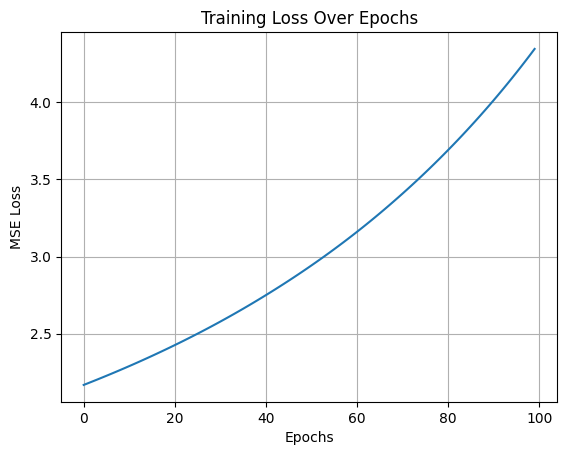

In [322]:
plt.plot(losses)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training Loss Over Epochs")
plt.grid(True)
plt.show()